In [5]:
import pandas as pd
from pathlib import Path


LOCAL_FOLDER = Path.cwd().parent.parent / "local_folder"
try:
        df = pd.read_csv(LOCAL_FOLDER / 'aggregated_company_data.csv')
except FileNotFoundError:
        print("Błąd: Nie znaleziono pliku aggregated_company_data.csv")

## Uzasadnienie Wyboru Zmiennych do Modelu Rozmytego (Fuzzy Logic)

Architektura systemu opiera się na **3 nieskorelowanych ze sobą wskaźnikach**, co pozwoliło uniknąć klątwy wymiarowości i zredukować bazę wiedzy do 27 przejrzystych reguł. Aby zachować spójność matematyczną modelu, wszystkie trzy zmienne działają w ujednoliconej logice inwestycyjnej: **„Im wyższa wartość, tym lepsza ocena”**.

#### 1. Wycena Rynkowa: `EarningsYield` (NetIncome / MarketCap_mean)
* **Zasada w modelu:** Im **WIĘCEJ**, tym lepiej (wysoka rentowność inwestycji).
* **Dlaczego ten wskaźnik?** Zrezygnowano z klasycznego wskaźnika P/E (Cena do Zysku), ponieważ generuje on matematyczną asymptotę (dzielenie przez zero) przy braku zysków. Odwrócenie go do postaci `EarningsYield` sprawia, że funkcja jest całkowicie ciągła. Spółki generujące straty po prostu przyjmują wartości ujemne, organicznie lądując na dole skali rozmytej bez konieczności stosowania dodatkowych, filtrów w kodzie.

#### 2. Jakość Rozwoju: `Risk-AdjustedGrowth` (GrowthRate_mean / GrowthRate_std)
* **Zasada w modelu:** Im **WIĘCEJ**, tym lepiej (stabilny rozwój).
* **Dlaczego ten wskaźnik?** Samo średnie tempo wzrostu to za mało, aby ocenić firmę. Wskaźnik ten dzieli tempo wzrostu przez jego odchylenie standardowe. W ten sposób model faworyzuje spółki rozwijające się w sposób przewidywalny i systematyczny, a karze te, których przychody drastycznie skaczą z roku na rok (wysokie ryzyko).

#### 3. Odpowiedzialność Zarządu: `ESG_Signal-to-Noise` (Stabilność ESG)
* **Zasada w modelu:** Im **WIĘCEJ**, tym lepiej (konsekwentna poprawa standardów).
* **Dlaczego ten wskaźnik?** Zwykła, punktowa ocena ESG często faworyzuje po prostu wielkie i bogate korporacje. Wskaźnik *Signal-to-Noise* mierzy natomiast dynamikę i uporządkowanie zmian. Dzięki niemu system rozmyty potrafi wyłapać "greenwashing" – karząc spółki o chaotycznej polityce niefinansowej, a nagradzając te, które wykazują stabilny trend poprawy.

c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


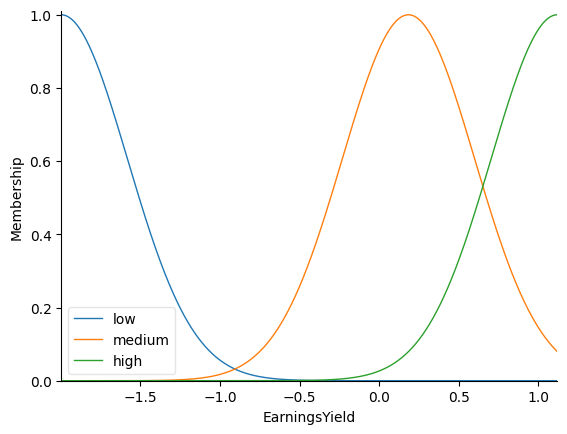

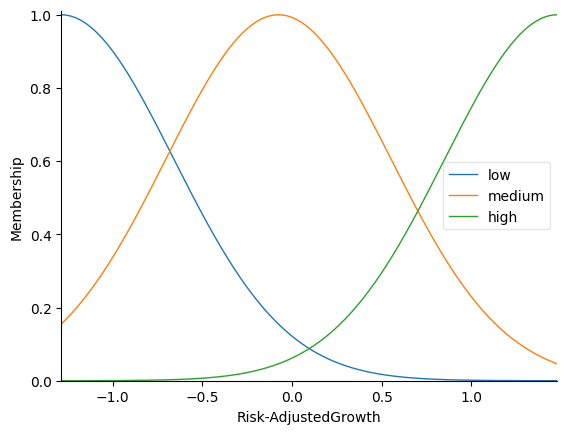

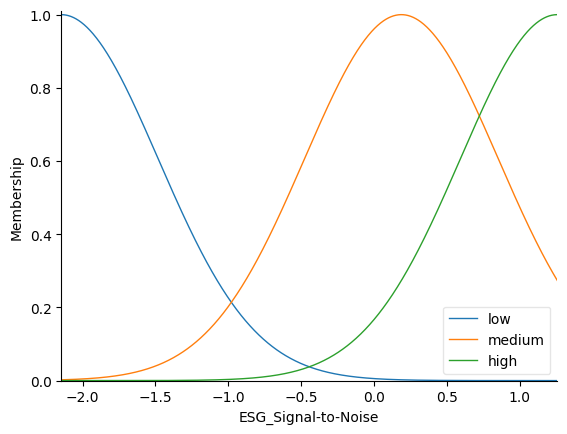

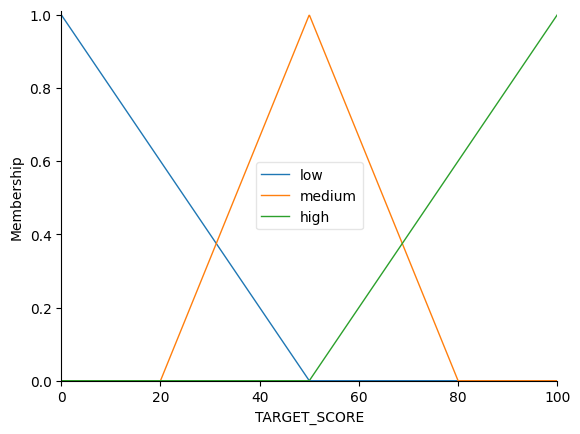

In [6]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Parametry przestrzeni rozważań (Universe of Discourse)
RESOLUTION = 1000
MIN_QUANTILE = 0.05
MAX_QUANTILE = 0.95

# Rozdzielczość osi X
RES = 1000

# Definicja uniwersów (zakresów) na podstawie kwantyli 5% i 95%
ey_min, ey_max = df['EarningsYield'].quantile(MIN_QUANTILE), df['EarningsYield'].quantile(MAX_QUANTILE)
rag_min, rag_max = df['Risk-AdjustedGrowth'].quantile(MIN_QUANTILE), df['Risk-AdjustedGrowth'].quantile(MAX_QUANTILE)
esg_min, esg_max = df['ESG_Signal-to-Noise'].quantile(MIN_QUANTILE), df['ESG_Signal-to-Noise'].quantile(MAX_QUANTILE)

# Tworzenie zmiennych (Antecedents)
ey = ctrl.Antecedent(np.linspace(ey_min, ey_max, RES), 'EarningsYield')
rag = ctrl.Antecedent(np.linspace(rag_min, rag_max, RES), 'Risk-AdjustedGrowth')
esg = ctrl.Antecedent(np.linspace(esg_min, esg_max, RES), 'ESG_Signal-to-Noise')
score = ctrl.Consequent(np.linspace(0, 100, RES), 'TARGET_SCORE')

# Statystyki do budowy funkcji Gaussa (mean, sigma)
def get_gauss_params(series, q_min, q_max):
    mean = series.median()
    sigma = (series.quantile(0.75) - series.quantile(0.25)) / 1.5
    return q_min, mean, q_max, sigma

# 'low' - centrowane na minimum, 'medium' - na medianie, 'high' - na maksimum (95%)
for var, col in zip([ey, rag, esg], ['EarningsYield', 'Risk-AdjustedGrowth', 'ESG_Signal-to-Noise']):
    mi, med, ma, sig = get_gauss_params(df[col], var.universe.min(), var.universe.max())
    var['low'] = fuzz.gaussmf(var.universe, mi, sig)
    var['medium'] = fuzz.gaussmf(var.universe, med, sig)
    var['high'] = fuzz.gaussmf(var.universe, ma, sig)

# Wyjście (Score) zostawiamy jako trójkąty dla jasnej defuzyfikacji
score['low'] = fuzz.trimf(score.universe, [0, 0, 50])
score['medium'] = fuzz.trimf(score.universe, [20, 50, 80])
score['high'] = fuzz.trimf(score.universe, [50, 100, 100])

# Wizualizacja
ey.view()
rag.view()
esg.view()
score.view()

### 2. Baza Wiedzy (27 Reguł)
Wszystkie trzy zmienne działają teraz w spójnej logice: **"Im wyższa wartość, tym lepiej"**. 
To sprawia, że reguły są intuicyjne i eliminują ryzyko nagrodzenia spółki za ujemny wskaźnik P/E.

In [7]:
# Reguły pogrupowane według EarningsYield (Głównego silnika zysku)
rules = [
    # EY is LOW (Słaba rentowność lub straty)
    ctrl.Rule(ey['low'] & rag['low'] & esg['low'], score['low']),
    ctrl.Rule(ey['low'] & rag['low'] & esg['medium'], score['low']),
    ctrl.Rule(ey['low'] & rag['low'] & esg['high'], score['medium']),
    ctrl.Rule(ey['low'] & rag['medium'] & esg['low'], score['low']),
    ctrl.Rule(ey['low'] & rag['medium'] & esg['medium'], score['medium']),
    ctrl.Rule(ey['low'] & rag['medium'] & esg['high'], score['medium']),
    ctrl.Rule(ey['low'] & rag['high'] & esg['low'], score['medium']),
    ctrl.Rule(ey['low'] & rag['high'] & esg['medium'], score['medium']),
    ctrl.Rule(ey['low'] & rag['high'] & esg['high'], score['high']),

    # EY is MEDIUM (Stabilna rentowność)
    ctrl.Rule(ey['medium'] & rag['low'] & esg['low'], score['low']),
    ctrl.Rule(ey['medium'] & rag['low'] & esg['medium'], score['medium']),
    ctrl.Rule(ey['medium'] & rag['low'] & esg['high'], score['medium']),
    ctrl.Rule(ey['medium'] & rag['medium'] & esg['low'], score['medium']),
    ctrl.Rule(ey['medium'] & rag['medium'] & esg['medium'], score['medium']),
    ctrl.Rule(ey['medium'] & rag['medium'] & esg['high'], score['high']),
    ctrl.Rule(ey['medium'] & rag['high'] & esg['low'], score['medium']),
    ctrl.Rule(ey['medium'] & rag['high'] & esg['medium'], score['high']),
    ctrl.Rule(ey['medium'] & rag['high'] & esg['high'], score['high']),

    # EY is HIGH (Świetna wycena / okazja)
    ctrl.Rule(ey['high'] & rag['low'] & esg['low'], score['medium']),
    ctrl.Rule(ey['high'] & rag['low'] & esg['medium'], score['medium']),
    ctrl.Rule(ey['high'] & rag['low'] & esg['high'], score['high']),
    ctrl.Rule(ey['high'] & rag['medium'] & esg['low'], score['medium']),
    ctrl.Rule(ey['high'] & rag['medium'] & esg['medium'], score['high']),
    ctrl.Rule(ey['high'] & rag['medium'] & esg['high'], score['high']),
    ctrl.Rule(ey['high'] & rag['high'] & esg['low'], score['high']),
    ctrl.Rule(ey['high'] & rag['high'] & esg['medium'], score['high']),
    ctrl.Rule(ey['high'] & rag['high'] & esg['high'], score['high'])
]

### 3. Uruchomienie Modelu i Zapis Wyników

In [8]:
output_path = LOCAL_FOLDER / 'scored_27_rules.csv'

scoring_system = ctrl.ControlSystem(rules)
simulation = ctrl.ControlSystemSimulation(scoring_system)

results = []

for idx, row in df.iterrows():
    try:
        simulation.input['EarningsYield'] = row['EarningsYield']
        simulation.input['Risk-AdjustedGrowth'] = row['Risk-AdjustedGrowth']
        simulation.input['ESG_Signal-to-Noise'] = row['ESG_Signal-to-Noise']
        
        simulation.compute()
        results.append(round(simulation.output['TARGET_SCORE'], 2))
    except Exception as e:
        results.append(np.nan)

df['TARGET_SCORE'] = results
df.to_csv(output_path, index=False)

print(f"Symulacja zakończona sukcesem! Plik zapisany w: {output_path}")
# display(df.sort_values(by='TARGET_SCORE', ascending=False).head(10))

df_sorted = df.sort_values(by='TARGET_SCORE', ascending=False)
display(df_sorted[['CompanyName', 'TARGET_SCORE']].head(5))

Symulacja zakończona sukcesem! Plik zapisany w: c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\local_folder\scored_27_rules.csv


,CompanyName,TARGET_SCORE
920,Company_921,80.81
410,Company_411,80.76
239,Company_240,80.73
433,Company_434,80.71
892,Company_893,79.90
